# **Topic 06: Curve & Parameter Fitting**: Supplementary Interactive Material


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit, least_squares

# 01: Michaelis–Menten Parameter Estimation:
## Linearization vs Nonlinear Least Squares (NLS)

In this notebook, we compare two approaches to fitting the Michaelis–Menten model, for reaction rate proportional to available substrate:

$$
V = \frac{V_{\max} S}{K_m + S}
$$

- **Linearization (Lineweaver–Burk):**
  Transform to a linear form using:
  $$
  \frac{1}{V} = \frac{K_m}{V_{\max}} \cdot \frac{1}{S} + \frac{1}{V_{\max}}
  $$
  Then apply simple linear regression.

- **Nonlinear Least Squares (NLS):**
  Fit directly to the original nonlinear model by minimizing:
  $$
  \sum_i \left( V_i - \frac{V_{\max} S_i}{K_m + S_i} \right)^2
  $$

We will compute parameter estimates, compare models, and analyze their fitting errors.


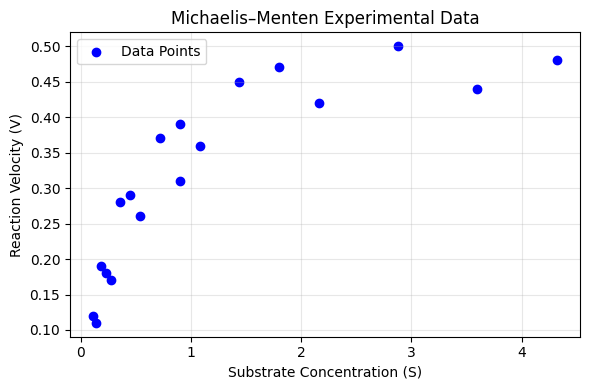

In [2]:
# Given Data
S = np.array([4.32, 2.16, 1.08, 0.54, 0.27, 0.135, 3.6, 1.8, 0.9, 0.45,
              0.225, 0.1125, 2.88, 1.44, 0.72, 0.36, 0.18, 0.9, 0])
V = np.array([0.48, 0.42, 0.36, 0.26, 0.17, 0.11, 0.44, 0.47, 0.39,
              0.29, 0.18, 0.12, 0.5, 0.45, 0.37, 0.28, 0.19, 0.31, 0])

mask = (S > 0) & (V > 0)
S_nonzero = S[mask]
V_nonzero = V[mask]

plt.figure(figsize=(6, 4))
plt.scatter(S_nonzero, V_nonzero, color='blue', label='Data Points')
plt.xlabel("Substrate Concentration (S)")
plt.ylabel("Reaction Velocity (V)")
plt.title("Michaelis–Menten Experimental Data")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## a). Linearization (Lineweaver–Burk Method)

Using the reciprocal transformation:

$$
\frac{1}{V} = \frac{K_m}{V_{\max}}\cdot \frac{1}{S} + \frac{1}{V_{\max}}
$$

This allows us to estimate slope and intercept using linear regression:
- Slope = $ K_m / V_{\max} $
- Intercept = $ 1 / V_{\max} $


Linearization Estimates:
  Vmax = 0.5272
  Km   = 0.4223


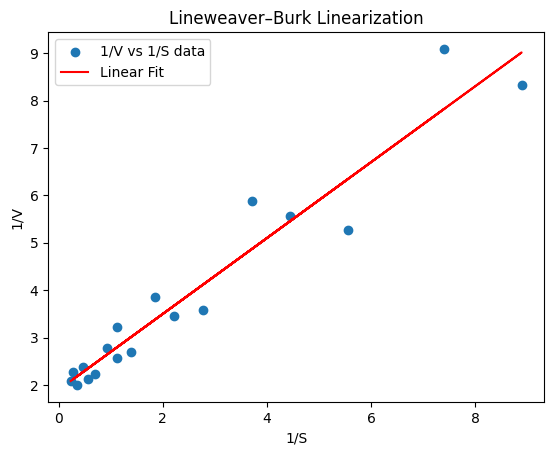

In [3]:
# Linearization
x = 1 / S_nonzero
y = 1 / V_nonzero
slope, intercept, r, p, se = linregress(x, y)

Vmax_lin = 1 / intercept
Km_lin = slope / intercept

print(f"Linearization Estimates:")
print(f"  Vmax = {Vmax_lin:.4f}")
print(f"  Km   = {Km_lin:.4f}")

# Plot
plt.scatter(x, y, label="1/V vs 1/S data")
plt.plot(x, slope*x + intercept, color='red', label="Linear Fit")
plt.xlabel("1/S")
plt.ylabel("1/V")
plt.title("Lineweaver–Burk Linearization")
plt.legend()
plt.show()


### b). Nonlinear Least Squares (NLS) — What Is Actually Happening?

Instead of linearizing the Michaelis–Menten equation, we directly fit the original nonlinear model:

$$
V(S; V_{\max}, K_m) = \frac{V_{\max} S}{K_m + S}
$$

We find parameters $(V_{\max}, K_m)$ that minimize the sum of squared errors:

$$
J(V_{\max}, K_m) = \sum_{i=1}^n \left[ V_i - \frac{V_{\max} S_i}{K_m + S_i} \right]^2
$$

Because this function is **nonlinear in the parameters**, there is no closed-form solution.  
We must solve it **iteratively**:

**A simple approach would be:**

1. Choose an initial guess $(V_{\max}^{(0)}, K_m^{(0)})$
2. Compute residuals: $r_i = V_i - f(S_i; \theta)$
3. Compute gradient of $J$ with respect to parameters
4. Update parameters using:
   $$
   \theta^{(k+1)} = \theta^{(k)} - \alpha \nabla J(\theta^{(k)})
   $$
   (Gradient Descent)

**In practice**, most software (e.g. `scipy.curve_fit`) uses the **Levenberg–Marquardt algorithm**, which updates:

$$
(\mathbf{J}^T \mathbf{J} + \lambda I)\Delta\theta = \mathbf{J}^T r
$$

This method balances **speed** (Gauss–Newton) and **stability** (Gradient Descent).

For the sake of this demonstration, we will use `scipy.curve_fit`


NLS Estimates:
  Vmax = 0.5332
  Km   = 0.4187

Model Fit (Sum of Squared Errors):
  Linearized Fit SSE = 0.0176
  NLS Fit SSE       = 0.0172


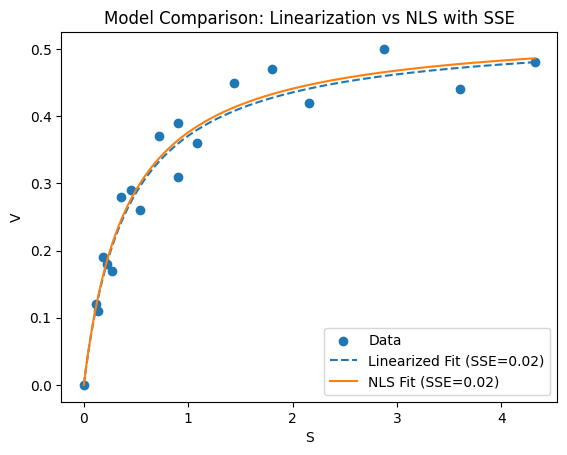

In [4]:

# Michaelis-Menten model
def MM(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

# Fit using Nonlinear Least Squares (NLS)
popt, _ = curve_fit(MM, S_nonzero, V_nonzero, p0=[Vmax_lin, Km_lin])
Vmax_nls, Km_nls = popt

# Predictions
V_pred_lin = MM(S, Vmax_lin, Km_lin)
V_pred_nls = MM(S, Vmax_nls, Km_nls)

# --- Sum of Squared Errors (SSE) ---
SSE_lin = np.sum((V - V_pred_lin)**2)
SSE_nls = np.sum((V - V_pred_nls)**2)

print(f"NLS Estimates:")
print(f"  Vmax = {Vmax_nls:.4f}")
print(f"  Km   = {Km_nls:.4f}")
print("\nModel Fit (Sum of Squared Errors):")
print(f"  Linearized Fit SSE = {SSE_lin:.4f}")
print(f"  NLS Fit SSE       = {SSE_nls:.4f}")

# Plot Fits
S_fit = np.linspace(0, max(S), 200)
plt.scatter(S, V, label="Data")
plt.plot(S_fit, MM(S_fit, Vmax_lin, Km_lin), '--', label=f"Linearized Fit (SSE={SSE_lin:.2f})")
plt.plot(S_fit, MM(S_fit, Vmax_nls, Km_nls), label=f"NLS Fit (SSE={SSE_nls:.2f})")
plt.xlabel("S")
plt.ylabel("V")
plt.title("Model Comparison: Linearization vs NLS with SSE")
plt.legend()
plt.show()

# 02: Damped Harmonic Oscillator — Simulation and Parameter Estimation

The **damped harmonic oscillator** is a classical physical system that models many real-world processes such as springs with friction, electrical RLC circuits, and molecular vibrations.

The governing second-order ODE is:

$$
\frac{d^2x}{dt^2} + 2\zeta \omega \frac{dx}{dt} + \omega^2 x = 0 ,
$$

where  
- $x(t)$ = displacement,  
- $\zeta$ = damping ratio,  
- $\omega$ = natural frequency.

To solve numerically, we convert this into a **first-order system**:

$$
\begin{aligned}
\frac{dx}{dt} &= v \\
\frac{dv}{dt} &= -2\zeta\omega v - \omega^2 x
\end{aligned}
$$

---

### Objective

We follow these steps:

1. **Simulate the system** using known parameters $\zeta_{\text{true}}$ and $\omega_{\text{true}}$.
2. **Generate noisy observations** to mimic real experimental data.
3. **Estimate the parameters** $\zeta$ and $\omega$ by minimizing the **sum of squared errors** between the model and data (nonlinear least squares).
4. **Compare the fitted model to the true dynamics** visually.

The optimization problem is:

$$
\min_{\zeta, \omega} \quad 
\sum_{i} \left[ x_{\text{obs}}(t_i) - x_{\text{model}}(t_i; \zeta, \omega) \right]^2
$$

---

After simulating and fitting, we compare:
- **True model vs noisy data vs fitted model**  
- Evaluate how well the optimization recovered $(\zeta, \omega)$.

---
For this demonstration, we will try using Gradient descent.


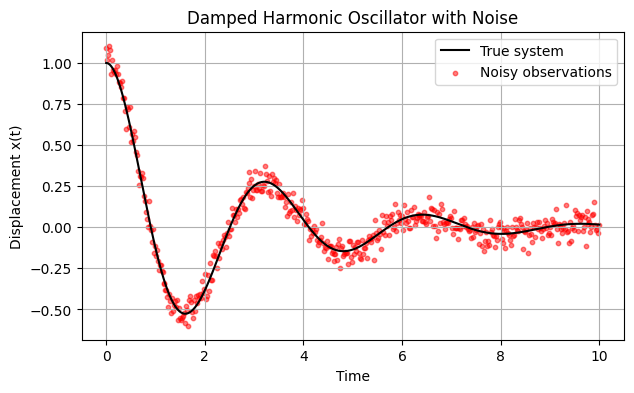

In [5]:

# ---- Damped harmonic oscillator ODE ----
def damped_oscillator(t, state, zeta, omega):
    x, v = state
    dxdt = v
    dvdt = -2 * zeta * omega * v - (omega**2) * x
    return [dxdt, dvdt]

# ---- True parameters ----
zeta_true = 0.2     # underdamped
omega_true = 2.0    # natural frequency
state0 = [1.0, 0.0] # initial displacement, zero velocity
t = np.linspace(0, 10, 500)

# ---- Simulate ----
solution = solve_ivp(lambda t, y: damped_oscillator(t, y, zeta_true, omega_true),
                     (t[0], t[-1]), state0, t_eval=t)

x_true = solution.y[0]

# ---- Add noisy synthetic observations ----
np.random.seed(0)
noise_level = 0.05
x_obs = x_true + noise_level * np.random.randn(len(x_true))

plt.figure(figsize=(7,4))
plt.plot(t, x_true, 'k-', label='True system')
plt.scatter(t, x_obs, s=10, color='red', alpha=0.5, label='Noisy observations')
plt.xlabel('Time')
plt.ylabel('Displacement x(t)')
plt.title('Damped Harmonic Oscillator with Noise')
plt.legend()
plt.grid(True)
plt.show()


In [6]:

# Loss function (SSE between model and observed data)
def loss(zeta, omega):
    sol = solve_ivp(lambda t, y: damped_oscillator(t, y, zeta, omega),
                    (t[0], t[-1]), state0, t_eval=t)
    x_model = sol.y[0]
    return np.sum((x_model - x_obs)**2)

# Numerical gradients dL/dzeta and dL/domega
def grad(zeta, omega, h=1e-4):
    L = loss(zeta, omega)
    dL_dzeta = (loss(zeta + h, omega) - L) / h
    dL_domega = (loss(zeta, omega + h) - L) / h
    return dL_dzeta, dL_domega

# --- Gradient Descent Loop ---
zeta_gd, omega_gd = 0.5, 1.0    # initial guesses
lr = 1e-3                       # learning rate
history = []

for i in range(100):            # 100 iterations max
    dLz, dLw = grad(zeta_gd, omega_gd)
    zeta_gd -= lr * dLz
    omega_gd -= lr * dLw

    L = loss(zeta_gd, omega_gd)
    history.append(L)

    if i % 10 == 0:
        print(f"Iter {i:2d} | ζ = {zeta_gd:.4f}, ω = {omega_gd:.4f}, Loss = {L:.6f}")

print("\nFinal parameters (Gradient Descent):")
print(f"ζ ≈ {zeta_gd:.4f}, ω ≈ {omega_gd:.4f}")

Iter  0 | ζ = 0.4942, ω = 1.0731, Loss = 50.332836
Iter 10 | ζ = 0.3390, ω = 1.6383, Loss = 15.800818
Iter 20 | ζ = 0.1964, ω = 1.9637, Loss = 1.471335
Iter 30 | ζ = 0.1993, ω = 2.0073, Loss = 1.232486
Iter 40 | ζ = 0.1999, ω = 2.0123, Loss = 1.229347
Iter 50 | ζ = 0.2000, ω = 2.0129, Loss = 1.229285
Iter 60 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283
Iter 70 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283
Iter 80 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283
Iter 90 | ζ = 0.2000, ω = 2.0130, Loss = 1.229283

Final parameters (Gradient Descent):
ζ ≈ 0.2000, ω ≈ 2.0130


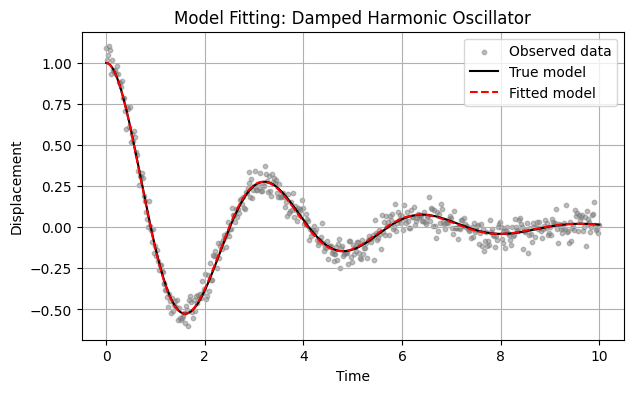

In [7]:
# Re-simulate using fitted parameters
sol_fit = solve_ivp(lambda t, y: damped_oscillator(t, y, zeta_gd, omega_gd),
                    (t[0], t[-1]), state0, t_eval=t)

x_fit = sol_fit.y[0]

plt.figure(figsize=(7,4))
plt.scatter(t, x_obs, s=10, color='gray', alpha=0.5, label='Observed data')
plt.plot(t, x_true, 'k-', label='True model')
plt.plot(t, x_fit, 'r--', label='Fitted model')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Model Fitting: Damped Harmonic Oscillator')
plt.legend()
plt.grid(True)
plt.show()


**While Gradient Descent proved successful here:** 

It often isn’t ideal for ODE parameter estimation because:
- Each step requires solving the ODE — it becomes slow.
- The loss surface is often non-convex — GD can get stuck.
- Choosing a learning rate that works is often a process of trial and error.

So GD works as a **demonstration**, but for real problems we use more reliable methods like Levenberg–Marquardt, trust-region solvers, or global methods like simulated annealing.